In [6]:
# a. Import required libraries
from ipywidgets import FileUpload
import io
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

In [7]:
# Load CSV without headers so columns are 0-140
data = pd.read_csv(r"C:\Users\Dipak\Downloads\ecg.csv", header=None)
print(data.shape)      # Should show (4997, 141)
print(data.head())

# Separate features and target
features = data.drop(140, axis=1)  # Columns 0-139
target = data[140]                 # Column 140

# Train/test split
x_train, x_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, stratify=target, random_state=42
)

# Train only on normal samples (label == 1)
train_index = y_train[y_train == 1].index
train_data = x_train.loc[train_index]

# Scale features to [0,1]
scaler = MinMaxScaler(feature_range=(0, 1))
x_train_scaled = scaler.fit_transform(train_data)
x_test_scaled = scaler.transform(x_test)


(4998, 141)
        0         1         2         3         4         5         6    \
0 -0.112522 -2.827204 -3.773897 -4.349751 -4.376041 -3.474986 -2.181408   
1 -1.100878 -3.996840 -4.285843 -4.506579 -4.022377 -3.234368 -1.566126   
2 -0.567088 -2.593450 -3.874230 -4.584095 -4.187449 -3.151462 -1.742940   
3  0.490473 -1.914407 -3.616364 -4.318823 -4.268016 -3.881110 -2.993280   
4  0.800232 -0.874252 -2.384761 -3.973292 -4.338224 -3.802422 -2.534510   

        7         8         9    ...       131       132       133       134  \
0 -1.818286 -1.250522 -0.477492  ...  0.792168  0.933541  0.796958  0.578621   
1 -0.992258 -0.754680  0.042321  ...  0.538356  0.656881  0.787490  0.724046   
2 -1.490659 -1.183580 -0.394229  ...  0.886073  0.531452  0.311377 -0.021919   
3 -1.671131 -1.333884 -0.965629  ...  0.350816  0.499111  0.600345  0.842069   
4 -1.783423 -1.594450 -0.753199  ...  1.148884  0.958434  1.059025  1.371682   

        135       136       137       138       139  140

In [8]:
class AutoEncoder(Model):
    def __init__(self, output_units, ldim=8):
        super().__init__()
        # Encoder
        self.encoder = Sequential([
            Dense(64, activation='relu'),
            Dropout(0.1),
            Dense(32, activation='relu'),
            Dropout(0.1),
            Dense(16, activation='relu'),
            Dropout(0.1),
            Dense(ldim, activation='relu')  # latent space
        ])
        # Decoder
        self.decoder = Sequential([
            Dense(16, activation='relu'),
            Dropout(0.1),
            Dense(32, activation='relu'),
            Dropout(0.1),
            Dense(64, activation='relu'),
            Dropout(0.1),
            Dense(output_units, activation='sigmoid')  # reconstruct input
        ])

    def call(self, inputs):
        encoded = self.encoder(inputs)
        decoded = self.decoder(encoded)
        return decoded


C:\Users\Dipak\anaconda3\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'auto_encoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "auto_encoder_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0109 - mse: 0.0246 - val_loss: 0.0132 - val_mse: 0.0307
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0107 - mse: 0.0242 - val_loss: 0.0131 - val_mse: 0.0304
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0104 - mse: 0.0235 - val_loss: 0.0128 - val_mse: 0.0298
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0097 - mse: 0.0220 - val_loss: 0.0123 - val_mse: 0.0287
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0085 - mse: 0.0192 - val_loss: 0.0122 - val_mse: 0.0283
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0073 - mse: 0.0164 - val_loss: 0.0126 - val_mse: 0.0291
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0064 - mse: 0.0143 - val_loss: 0.0119 - val_mse: 0.0275
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0056 - mse: 0.0127 - val_loss: 0.0117 - val_mse: 0.0271
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0051 - mse: 0.0115 -

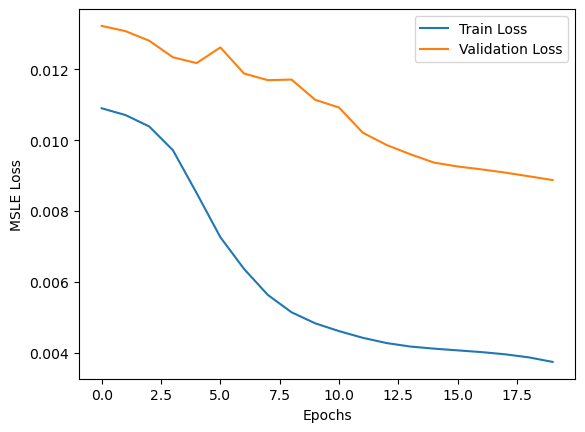

In [9]:
model = AutoEncoder(output_units=x_train_scaled.shape[1])

model.compile(
    optimizer='adam',
    loss='msle',
    metrics=['mse']
)

# Optional: check model summary
model.build(input_shape=(None, x_train_scaled.shape[1]))
model.summary()

# Train model
history = model.fit(
    x_train_scaled,
    x_train_scaled,
    epochs=20,
    batch_size=512,
    validation_data=(x_test_scaled, x_test_scaled)
)

# Plot training & validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSLE Loss')
plt.legend()
plt.show()
